# Model Comparison Analysis

In [7]:
from pathlib import Path
import json
import os
import sys
import time

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "dataset.yaml").exists():
    PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

DATASET_YAML = PROJECT_ROOT / "data" / "dataset.yaml"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
METRIC_DIR = REPORT_DIR / "trained_metrics"
MODEL_DIR = PROJECT_ROOT / "trained_models"
PROCESSED_DIR = PROJECT_ROOT / "processed_dataset"

for folder in [REPORT_DIR, FIGURE_DIR, METRIC_DIR, MODEL_DIR, PROCESSED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TRAINING = os.getenv("RUN_TRAINING", "0") == "1"
EVALUATE_MODEL = os.getenv("EVALUATE_MODEL", "1") == "1"
EPOCHS = int(os.getenv("EPOCHS", "100"))
IMAGE_SIZE = int(os.getenv("IMAGE_SIZE", "640"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "8"))

print("Project root:", PROJECT_ROOT)
print("Dataset yaml:", DATASET_YAML)
print("Run training:", RUN_TRAINING)
print("Evaluate model:", EVALUATE_MODEL)

Project root: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection
Dataset yaml: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\data\dataset.yaml
Run training: False
Evaluate model: True


# Load Trained Metrics

In [8]:
import pandas as pd
from IPython.display import display

expected_files = {
    "YOLOv8": METRIC_DIR / "yolov8_metrics.json",
    "Faster R-CNN": METRIC_DIR / "faster_rcnn_metrics.json",
    "SSD": METRIC_DIR / "ssd_metrics.json",
}

missing = [f"{name}: {path}" for name, path in expected_files.items() if not path.exists()]
if missing:
    message = "Comparison cannot run because trained metrics are missing."
    message += "\n" + "\n".join(missing)
    message += "\nRun each model notebook training/evaluation first."
    raise FileNotFoundError(message)

rows = []
for model_name, path in expected_files.items():
    row = json.loads(path.read_text(encoding="utf-8"))
    row["source_file"] = path.name
    rows.append(row)

df = pd.DataFrame(rows).set_index("model")

numeric_metrics = [
    "precision",
    "recall",
    "f1_score",
    "mAP50",
    "mAP50_95",
    "inference_ms",
    "fps",
    "training_time_min",
    "model_size_mb",
]
optional_text_columns = ["score_threshold", "detection_mode", "metric_note", "source_file"]

for col in numeric_metrics:
    if col not in df.columns:
        df[col] = pd.NA
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in optional_text_columns:
    if col not in df.columns:
        df[col] = ""
    df[col] = df[col].fillna("")

ordered_columns = numeric_metrics + [col for col in optional_text_columns if col in df.columns]
df = df[ordered_columns]

display_df = df.copy()
for col in numeric_metrics:
    display_df[col] = display_df[col].map(lambda value: "" if pd.isna(value) else round(float(value), 4))
for col in optional_text_columns:
    display_df[col] = display_df[col].fillna("")

display(display_df)
display_df.to_csv(REPORT_DIR / "model_comparison_metrics.csv")
print("Saved comparison table:", REPORT_DIR / "model_comparison_metrics.csv")


,precision,recall,f1_score,mAP50,mAP50_95,inference_ms,fps,training_time_min,model_size_mb,score_threshold,detection_mode,metric_note,source_file
model,,,,,,,,,,,,,
YOLOv8,0.9487,0.9120,0.9300,0.9471,0.7292,19.3968,51.5549,352.5836,5.9673,,,,yolov8_metrics.json
Faster R-CNN,0.4364,0.7500,0.5517,0.4364,0.4364,26.9831,37.0603,0.4687,72.5705,,,,faster_rcnn_metrics.json
SSD,0.7120,0.6953,0.7036,0.7120,0.7120,20.7639,48.1605,3.5177,14.4892,0.7,class_agnostic_uav,SSD is evaluated as a binary UAV detector when...,ssd_metrics.json


Saved comparison table: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\model_comparison_metrics.csv


# Bar Charts

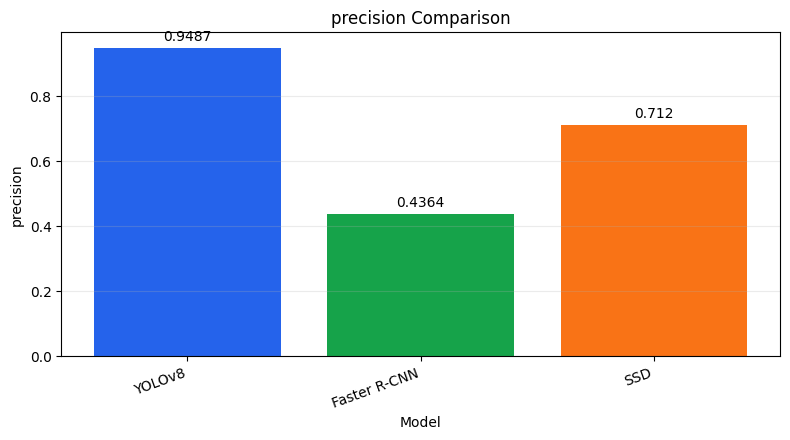

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\precision_comparison.png


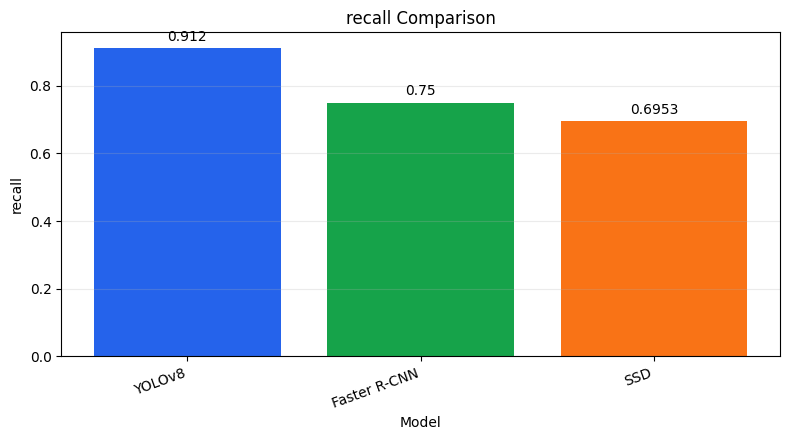

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\recall_comparison.png


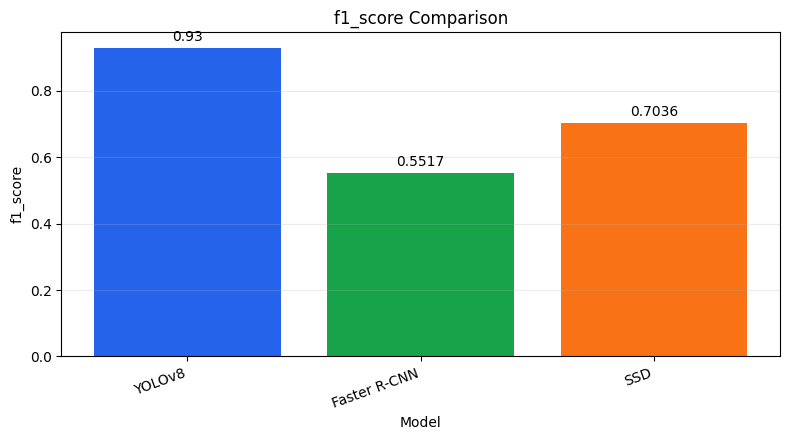

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\f1_score_comparison.png


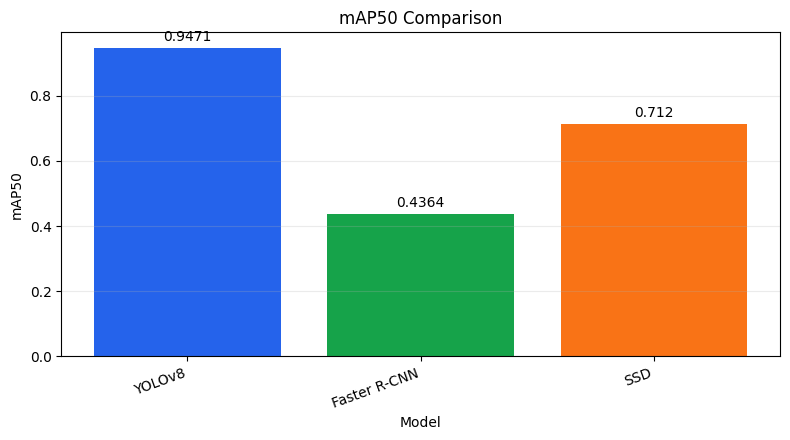

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\mAP50_comparison.png


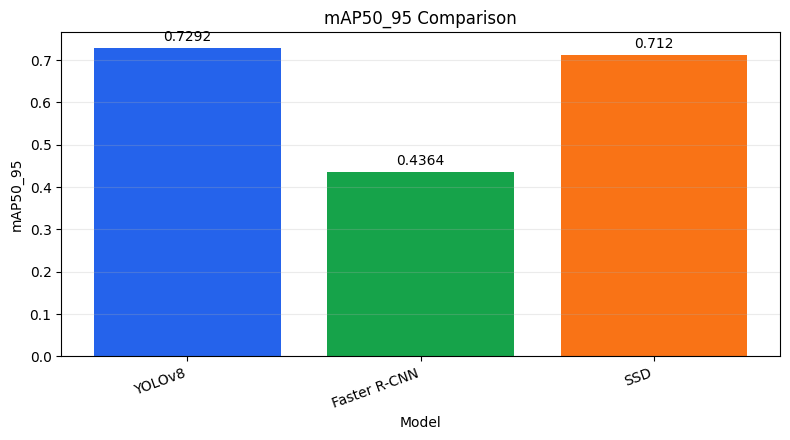

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\mAP50_95_comparison.png


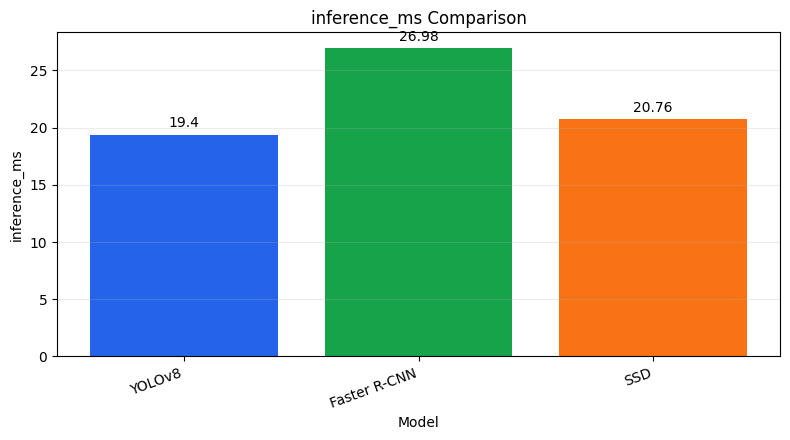

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\inference_ms_comparison.png


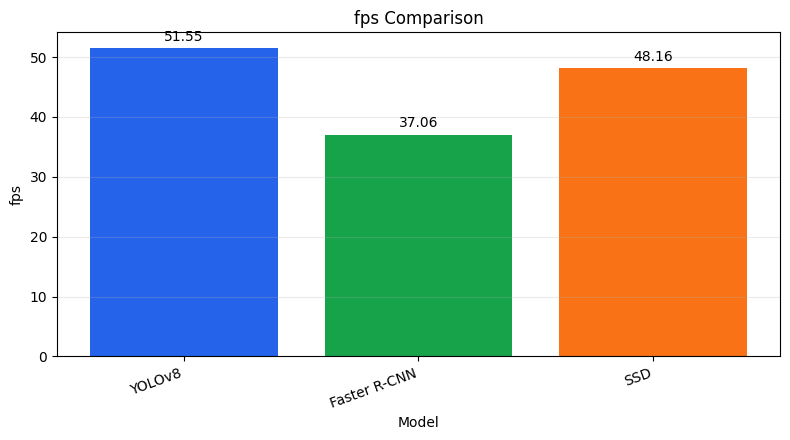

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\fps_comparison.png


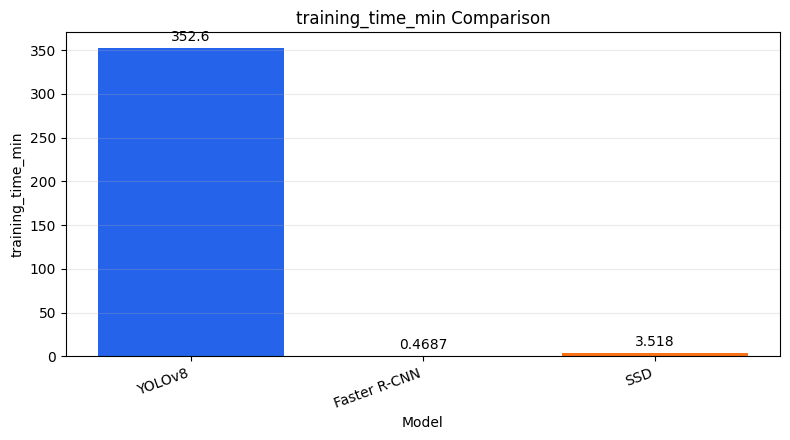

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\training_time_min_comparison.png


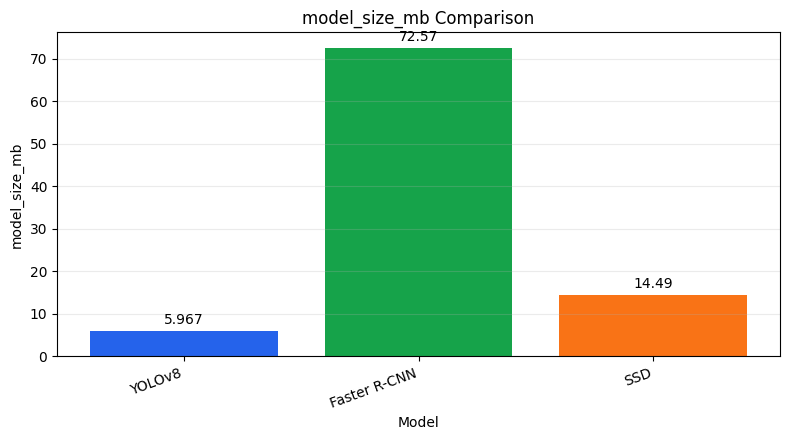

Saved: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\figures\model_size_mb_comparison.png
Saved and displayed comparison bar charts.


In [9]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "precision",
    "recall",
    "f1_score",
    "mAP50",
    "mAP50_95",
    "inference_ms",
    "fps",
    "training_time_min",
    "model_size_mb",
]

chart_df = df[metrics_to_plot].apply(pd.to_numeric, errors="coerce")

for metric in metrics_to_plot:
    values = chart_df[metric].dropna()
    if values.empty:
        print(f"Skipped {metric}: no numeric values available.")
        continue

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(values.index, values.values, color=["#2563eb", "#16a34a", "#f97316"][: len(values)])
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.set_xlabel("Model")
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(bars, labels=[f"{value:.4g}" for value in values.values], padding=3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    output_path = FIGURE_DIR / f"{metric}_comparison.png"
    plt.savefig(output_path, dpi=220)
    plt.show()
    plt.close(fig)
    print("Saved:", output_path)

print("Saved and displayed comparison bar charts.")


# Radar Chart

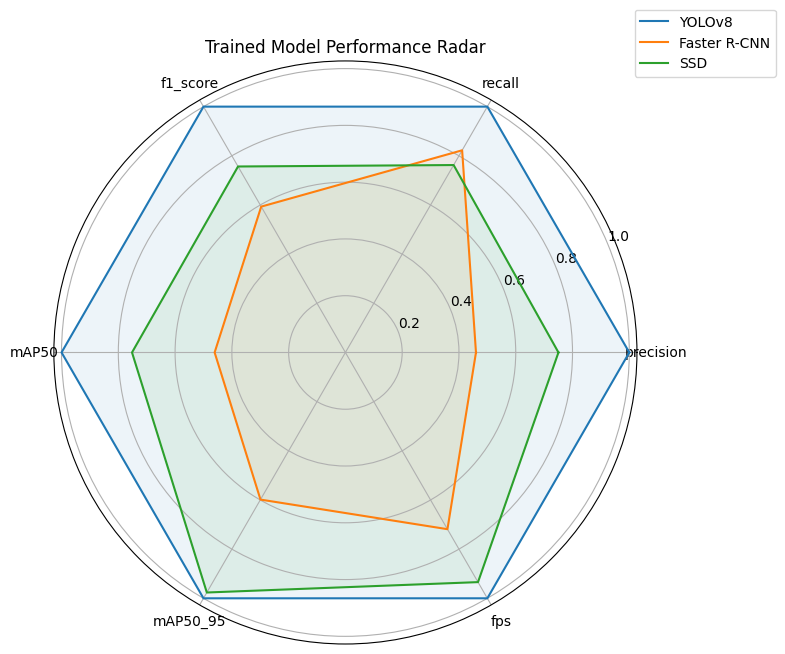

In [10]:
import numpy as np
import matplotlib.pyplot as plt

radar_metrics = ["precision", "recall", "f1_score", "mAP50", "mAP50_95", "fps"]
radar_df = df[radar_metrics].apply(pd.to_numeric, errors="coerce").dropna(how="all")
normalized = radar_df.copy()
for col in normalized.columns:
    max_value = normalized[col].max(skipna=True)
    normalized[col] = normalized[col] / max_value if pd.notna(max_value) and max_value else normalized[col]
normalized = normalized.fillna(0)

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
for model_name, row in normalized.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model_name)
    ax.fill(angles, values, alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics)
ax.set_title("Trained Model Performance Radar")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_radar_chart.png", dpi=220)
plt.show()
plt.close(fig)


# Heatmap

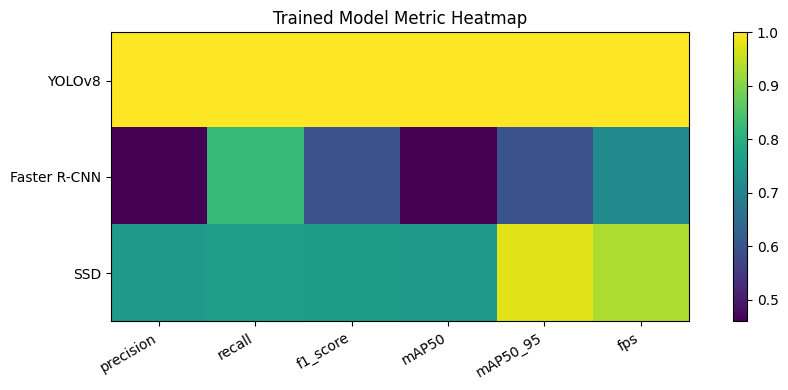

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
heatmap_values = normalized.values
heatmap = ax.imshow(heatmap_values, cmap="viridis")
ax.set_xticks(range(len(radar_metrics)))
ax.set_xticklabels(radar_metrics, rotation=30, ha="right")
ax.set_yticks(range(len(normalized.index)))
ax.set_yticklabels(normalized.index)
fig.colorbar(heatmap, ax=ax)
ax.set_title("Trained Model Metric Heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_metric_heatmap.png", dpi=220)
plt.show()
plt.close(fig)


# Ranking Table

In [12]:
ranking = df.copy()
for col in numeric_metrics:
    ranking[col] = pd.to_numeric(ranking[col], errors="coerce")

ranking["speed_score"] = ranking["fps"] / ranking["fps"].max(skipna=True)
max_size = ranking["model_size_mb"].max(skipna=True)
ranking["size_score"] = 1 - (ranking["model_size_mb"] / max_size) if max_size else 0
ranking["surveillance_score"] = (
    ranking["mAP50"] * 0.35
    + ranking["f1_score"] * 0.25
    + ranking["speed_score"] * 0.25
    + ranking["size_score"] * 0.15
)
ranking = ranking.sort_values("surveillance_score", ascending=False)
ranking_display = ranking.copy()
for col in ranking_display.columns:
    if pd.api.types.is_numeric_dtype(ranking_display[col]):
        ranking_display[col] = ranking_display[col].map(lambda value: "" if pd.isna(value) else round(float(value), 4))
    else:
        ranking_display[col] = ranking_display[col].fillna("")
ranking_display.to_csv(REPORT_DIR / "model_ranking_table.csv")
display(ranking_display)
print("Saved ranking table:", REPORT_DIR / "model_ranking_table.csv")


,precision,recall,f1_score,mAP50,mAP50_95,inference_ms,fps,training_time_min,model_size_mb,score_threshold,detection_mode,metric_note,source_file,speed_score,size_score,surveillance_score
model,,,,,,,,,,,,,,,,
YOLOv8,0.9487,0.9120,0.9300,0.9471,0.7292,19.3968,51.5549,352.5836,5.9673,,,,yolov8_metrics.json,1.0000,0.9178,0.9516
SSD,0.7120,0.6953,0.7036,0.7120,0.7120,20.7639,48.1605,3.5177,14.4892,0.7,class_agnostic_uav,SSD is evaluated as a binary UAV detector when...,ssd_metrics.json,0.9342,0.8003,0.7787
Faster R-CNN,0.4364,0.7500,0.5517,0.4364,0.4364,26.9831,37.0603,0.4687,72.5705,,,,faster_rcnn_metrics.json,0.7188,0.0000,0.4704


Saved ranking table: C:\Users\nagas\Downloads\Drone_Detection\Drone_Detection\reports\model_ranking_table.csv
